# Stats visualizer (decoupled protocol)

Two result stores:
* **`lab/output/results/`** - article runs (with per-instance cf dumps).
* **`lab/output/results-legacy/`** - thesis/paper runs (no cf dumps), treated
  as **seedless** but pooled into the cf-free tables.

Protocol (REVISION_EXPERIMENTS.md): every (dataset, generator, minimizer)
runs ONCE (no-seed = internal seed 0). Multiple seeds ONLY for LBS+DCE.

Sections:
* **3. Table A** - no-seed matrix, all minimizers, GED/FED/OC as mean ± global std.
* **3b. Correctness** - one value per generator (DBS equalised / excluded).
* **4. Bars**, **5. Wilcoxon (LBS vs OBS)**.
* **6. Table B** - LBS+DCE stability across seeds (E1b).
* **7. E3** ordering ablation (second batch), **7b.** BLS variants view.
* **8. Coverage**, **9. per-scope CSV** (both stores).

GED/FED average only over correct counterfactuals; FED only on attributed
datasets (synthie, bbbp). Re-run top-to-bottom after each batch.

## 1. Setup

In [1]:
import os
import re
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

module_path = os.path.abspath(os.path.join('..'))
sys.path.insert(0, module_path)
os.chdir(module_path)

# Two result stores (decoupled protocol):
#   results/         - article runs WITH per-instance cf dumps.
#   results-legacy/  - older thesis/paper runs WITHOUT cf dumps (seedless).
RESULTS_ROOT   = Path('lab/output/results')
RESULTS_LEGACY = Path('lab/output/results-legacy')
LEGACY_SEED    = -1   # sentinel seed for legacy rows (seedless)

DATASETS    = ['asd', 'synthie', 'bbbp', 'tcr-tco-300']
GENERATORS  = ['dce', 'ofs', 'dfs', 'rsgg']
MINIMIZERS  = ['lcls', 'obs', 'dbs', 'rhc']
ATTRIBUTED  = {'synthie', 'bbbp'}            # FED only meaningful here

METRICS = ['GraphEditDistance', 'FeatureEditDistance', 'OracleCalls', 'Correctness']
PRETTY  = {'GraphEditDistance': 'GED', 'FeatureEditDistance': 'FED',
           'OracleCalls': 'OC', 'Correctness': 'Correctness'}

# Scope grammar (decoupled protocol):
#   no-seed single run:   <ds>_<gen>_<min>          -> seed 0 (canonical run)
#   LBS stability seeds:  <ds>_dce_lcls_seed<N>     -> seed N (N>=1)
#   E3 ordering ablation: <ds>_<gen>_<min>-var-<n>  -> seed 0 (min token = lcls-var-n)
# Legacy store: any <ds>_<gen>_<min> -> seed = LEGACY_SEED (seedless).
SCOPE_RE = re.compile(
    r'^(?P<ds>.+?)_'
    r'(?P<gen>dce|ofs|dfs|rsgg|dcm)_'
    r'(?P<min>[a-z0-9-]+?)'
    r'(?:_seed(?P<seed>\d+))?$'
)

def parse_scope(scope, legacy=False):
    """Return (ds, gen, min, seed) or None.

    Legacy store -> seed=LEGACY_SEED. Otherwise a bare <ds>_<gen>_<min>
    (the no-seed canonical run) is seed 0; ``_seed<N>`` keeps N."""
    m = SCOPE_RE.match(scope)
    if not m:
        return None
    if legacy:
        return m['ds'], m['gen'], m['min'], LEGACY_SEED
    seed = int(m['seed']) if m['seed'] is not None else 0
    return m['ds'], m['gen'], m['min'], seed


## 2. Long-form loader

Each row = one (scope, fold, instance, metric) tuple. From this single
DataFrame we derive every aggregation below.

In [2]:
import jsonpickle  # result files are jsonpickle-encoded; some metric values
                    # (e.g. FED) are numpy scalars stored as {'py/reduce': ...}
                    # dicts that plain json.loads leaves un-decoded.

def _as_float(v):
    """Coerce a decoded metric value to float, or None if not numeric."""
    try:
        return float(v)
    except (TypeError, ValueError):
        return None

def _load_store(results_root, legacy):
    """Load every results_*.json under a store into long-form rows.

    ``legacy=True`` tags rows with seed=LEGACY_SEED (seedless) and uses the
    legacy scope grammar. Returns a list of dicts.

    Each row carries its own ``is_correct`` flag, taken from the Correctness
    stage entry at the SAME position in the file. Stage lists are written in
    one record order, so position pairing is exact. This matters because some
    datasets (e.g. tcr-tco-300) store several counterfactual records per
    instance id: a later id-based merge would cross-join those records and
    pull a failed record's GED=0 into the correct set. ``rec`` is the within
    -file record index, kept so downstream joins are per-record, not per-id."""
    rows = []
    n_files = 0
    if not results_root.is_dir():
        return rows, n_files
    for f in results_root.rglob('results_*.json'):
        m = re.match(r'results_(\d+)_(\d+)\.json', f.name)
        if not m:
            continue
        n_files += 1
        fold, run = int(m.group(1)), int(m.group(2))
        try:
            data = jsonpickle.decode(f.read_text())  # decodes numpy scalars (FED)
            scope = data['config']['scope']
        except Exception:
            continue
        ps = parse_scope(scope, legacy=legacy)
        if ps is None:
            continue
        ds, gen, mn, seed = ps
        results = data.get('results', {})
        # correctness flags, positionally aligned with every stage list
        corr_key = next((k for k in results
                         if k.rsplit('.', 1)[-1] == 'Correctness'), None)
        corr_flags = [((_as_float(e.get('value')) or 0.0) > 0.5)
                      for e in results.get(corr_key, [])] if corr_key else []
        for stage_key, entries in results.items():
            metric = stage_key.rsplit('.', 1)[-1]
            if metric not in METRICS:
                continue
            aligned = (len(entries) == len(corr_flags))
            for idx, entry in enumerate(entries):
                fv = _as_float(entry.get('value'))
                if fv is None:
                    continue
                rows.append({
                    'scope': scope, 'fold': fold, 'run': run,
                    'inst_id': str(entry.get('id')), 'rec': idx,
                    'metric': metric, 'value': fv,
                    'is_correct': bool(corr_flags[idx]) if aligned else True,
                    'ds': ds, 'gen': gen, 'min_kind': mn, 'seed': seed,
                    'source': 'legacy' if legacy else 'results',
                })
    return rows, n_files

# results/ (seeded, has cf) + results-legacy/ (seedless, no cf). Both feed the
# cf-free aggregations; legacy is tagged seed=LEGACY_SEED.
rows_main, n_main = _load_store(RESULTS_ROOT, legacy=False)
rows_leg,  n_leg  = _load_store(RESULTS_LEGACY, legacy=True)
print(f"results/        {n_main} files -> {len(rows_main)} rows")
print(f"results-legacy/ {n_leg} files -> {len(rows_leg)} rows (seedless)")

df_long = pd.DataFrame(rows_main + rows_leg)

# --- Per-record correctness flag ---------------------------------------
# The framework only averages GED/FED over *correct* counterfactuals
# (see GraphEditDistance.aggregate / FeatureEditDistance.aggregate): a
# non-CF record writes GED=0.0, and including those zeros would deflate the
# mean. ``is_correct`` is attached per record at load time (by position, see
# _load_store) rather than merged by instance id, so datasets with several
# records per id (tcr-tco-300) are handled correctly. OC and Correctness are
# aggregated over *all* records (OC is a cost metric; Correctness is the
# fraction itself).
CORRECTNESS_FILTERED = {'GraphEditDistance', 'FeatureEditDistance'}
n_noncf = (~df_long[df_long['metric'] == 'Correctness']['is_correct']).sum()
print(f"  non-counterfactual records (excluded from GED/FED): {n_noncf}")
df_long.head()

results/        1031 files -> 318960 rows
results-legacy/ 176 files -> 55168 rows (seedless)
  non-counterfactual records (excluded from GED/FED): 19563


,scope,fold,run,inst_id,rec,metric,value,is_correct,ds,gen,min_kind,seed,source
0,asd_dce_rhc,6,1,22,0,GraphEditDistance,12.0,True,asd,dce,rhc,0,results
1,asd_dce_rhc,6,1,25,1,GraphEditDistance,6.0,True,asd,dce,rhc,0,results
2,asd_dce_rhc,6,1,27,2,GraphEditDistance,37.0,True,asd,dce,rhc,0,results
3,asd_dce_rhc,6,1,30,3,GraphEditDistance,18.0,True,asd,dce,rhc,0,results
4,asd_dce_rhc,6,1,48,4,GraphEditDistance,12.0,True,asd,dce,rhc,0,results


## 3. Table A - paper matrix (no-seed)

**4 main datasets × 4 generators × {bls, obs, dbs, rhc}**, single no-seed
run per cell (legacy pooled in). For each metric, mean and its global std
(over folds) are shown side by side: column `GED` = mean, column
`GED-std` = `± std` (same for FED, OC). Dataset / generator labels are
printed once per group with a blank spacer between datasets. FED only on
attributed datasets (synthie, bbbp). The BLS variants and the full
all-datasets picture live in `stats_visualizer_global.ipynb`.

In [3]:
def aggregate(df_long):
    """per_fold and per_seed views. GED/FED only over correct CFs;
    OC/Correctness over all instances. Legacy rows carry seed=LEGACY_SEED."""
    mask = df_long['metric'].isin(CORRECTNESS_FILTERED) & (~df_long['is_correct'])
    df_eff = df_long[~mask]
    per_fold = (df_eff.groupby(['ds','gen','min_kind','seed','fold','metric'])
                      ['value'].mean().reset_index())
    per_seed = (per_fold.groupby(['ds','gen','min_kind','seed','metric'])
                        ['value'].mean().reset_index())
    return per_fold, per_seed

per_fold, per_seed = aggregate(df_long)

# No-seed runs (seed 0) + legacy (seedless), pooled over folds. std = global
# std over those folds (no seed dimension).
def noseed_agg(per_fold):
    ns = per_fold[per_fold['seed'].isin([0])]  # legacy (seed -1) no longer counted
    return (ns.groupby(['ds','gen','min_kind','metric'])['value']
              .agg(mean='mean', std='std', n_runs='count').reset_index())

agg_noseed = noseed_agg(per_fold)
agg_noseed_core = agg_noseed[~agg_noseed['min_kind'].str.contains('-var-')].copy()

# Paper table: 4 main datasets x 4 generators x {bls, obs, dbs, rhc}.
PAPER_MINIMIZERS = ['lcls', 'obs', 'dbs', 'rhc']
agg_paper = agg_noseed_core[
    agg_noseed_core['ds'].isin(DATASETS)
    & agg_noseed_core['gen'].isin(GENERATORS)
    & agg_noseed_core['min_kind'].isin(PAPER_MINIMIZERS)].copy()

DEC = {'GraphEditDistance': 2, 'FeatureEditDistance': 2,
       'OracleCalls': 1, 'Correctness': 3}
METRIC_COLS = ['GraphEditDistance', 'FeatureEditDistance', 'OracleCalls']

def _order_key(col, order):
    return {v: i for i, v in enumerate(order)}.get(col, len(order))

def metric_table(agg, metrics=METRIC_COLS,
                 ds_order=None, gen_order=None, min_order=None,
                 group=True):
    """One row per (ds, gen, min). Mean and std side by side:
    '<M>' = mean, '<M>-std' = '± std'. FED blanked on non-attributed ds.
    If group=True, repeated ds/gen labels are blanked and a spacer row is
    inserted between datasets (display only)."""
    ds_order  = ds_order  or DATASETS
    gen_order = gen_order or GENERATORS
    min_order = min_order or PAPER_MINIMIZERS
    metric_cols = ['ds','gen','min'] + [c for m in metrics
                  for c in (PRETTY[m], PRETTY[m]+'-std')]

    recs = []
    for (ds, gen, mn), grp in agg.groupby(['ds','gen','min_kind']):
        rec = {'ds': ds, 'gen': gen, 'min': mn,
               '_ds': _order_key(ds, ds_order), '_gen': _order_key(gen, gen_order),
               '_min': _order_key(mn, min_order)}
        attr = ds in ATTRIBUTED
        for metric in metrics:
            row = grp[grp['metric'] == metric]
            d = DEC.get(metric, 2)
            P = PRETTY[metric]
            if metric == 'FeatureEditDistance' and not attr:
                rec[P], rec[P+'-std'] = '-', '-'
            elif row.empty or pd.isna(row['mean'].iloc[0]):
                rec[P], rec[P+'-std'] = '-', '-'
            else:
                rec[P] = f"{row['mean'].iloc[0]:.{d}f}"
                s = row['std'].iloc[0]
                rec[P+'-std'] = '' if pd.isna(s) else f"± {s:.{d}f}"
        recs.append(rec)

    if not recs:
        return pd.DataFrame(columns=metric_cols)

    df = (pd.DataFrame(recs).sort_values(['_ds','_gen','_min'])
            .drop(columns=['_ds','_gen','_min'])[metric_cols].reset_index(drop=True))
    if not group:
        return df

    # Display grouping: blank repeated ds/gen, spacer row between datasets.
    out_rows, prev_ds, prev_gen = [], None, None
    blank = {c: '' for c in df.columns}
    for _, r in df.iterrows():
        r = r.to_dict()
        if prev_ds is not None and r['ds'] != prev_ds:
            out_rows.append(dict(blank))          # spacer between datasets
        show_ds  = r['ds']  != prev_ds
        show_gen = show_ds or (r['gen'] != prev_gen)
        prev_ds, prev_gen = r['ds'], r['gen']
        if not show_ds:  r['ds']  = ''
        if not show_gen: r['gen'] = ''
        out_rows.append(r)
    return pd.DataFrame(out_rows, columns=df.columns)

print("Table A - no-seed paper matrix (4 ds x 4 gen x {bls,obs,dbs,rhc})")
print("mean with its global std (± col) side by side; FED only on synthie/bbbp")
tableA = metric_table(agg_paper)
tableA


Table A - no-seed paper matrix (4 ds x 4 gen x {bls,obs,dbs,rhc})
mean with its global std (± col) side by side; FED only on synthie/bbbp


,ds,gen,min,GED,GED-std,FED,FED-std,OC,OC-std
0,asd,dce,lcls,9.30,± 2.08,-,-,3716.4,± 1184.3
1,,,obs,9.68,± 2.15,-,-,2008.0,± 0.0
2,,,dbs,553.88,± 26.46,-,-,4106.0,± 0.0
3,,,rhc,11.24,± 3.50,-,-,4829.3,± 1037.8
4,,ofs,lcls,10.80,± 1.97,-,-,3649.1,± 872.9
...,...,...,...,...,...,...,...,...,...
62,,,rhc,1.01,± 0.02,-,-,521.5,± 37.3
63,,rsgg,lcls,1.79,± 0.20,-,-,428.5,± 18.7
64,,,obs,28.41,± 0.45,-,-,1288.2,± 224.0
65,,,dbs,28.45,± 0.38,-,-,1285.5,± 205.0


### 3b. Correctness - one value per generator

Correctness is a property of the **generator** (whether it produced a
valid CF), not of the minimizer (R2.6). Reported once per (dataset,
generator).

**DBS caveat:** there is a small discrepancy in DBS's correctness (a known
issue, DBS to be re-run later). For now DBS is *excluded* when computing
the per-generator correctness, so the reference value comes from the
agreeing minimizers (obs/lcls/rhc) - i.e. DBS is equalised to the rest.

In [4]:
# Per-generator correctness (no-seed runs). Computed from the agreeing
# minimizers (exclude DBS, whose correctness has a known discrepancy);
# this is the value DBS is "equalised" to in the metrics tables.
corr = agg_noseed_core[agg_noseed_core['metric'] == 'Correctness'].copy()
corr_ref = corr[corr['min_kind'] != 'dbs']           # exclude DBS for the reference
correctness_by_gen = (corr_ref.groupby(['ds', 'gen'])['mean']
                              .mean().reset_index(name='correctness'))
correctness_tbl = correctness_by_gen.pivot(index='ds', columns='gen',
                                            values='correctness').round(3)

# Sanity: spread across the (non-DBS) minimizers — should be ~0 if correctness
# is purely a generator property.
spread = (corr_ref.groupby(['ds', 'gen'])['mean'].std()
                  .reset_index(name='std').pivot(index='ds', columns='gen', values='std'))
print("Correctness per (dataset, generator)  [DBS excluded -> equalised]")
display(correctness_tbl)



Correctness per (dataset, generator)  [DBS excluded -> equalised]


gen,dce,dfs,ofs,rsgg
ds,,,,
asd,1.0,1.000,0.773,0.452
bbbp,1.0,0.607,0.797,0.468
synthie,1.0,0.739,0.737,0.711
tcr-tco-300,1.0,0.506,0.864,0.827


## 4. E1 - Bar charts with error bars

One figure per metric (GED, FED, OC). Each figure has 4 panels, one per
generator; within a panel, datasets on the x-axis and minimizers as
grouped bars. Error bars = std across the 3 seeds.

R2.8: single shared legend at the figure level.
R2.9: FED only on attributed datasets (Synthie, BBBP).

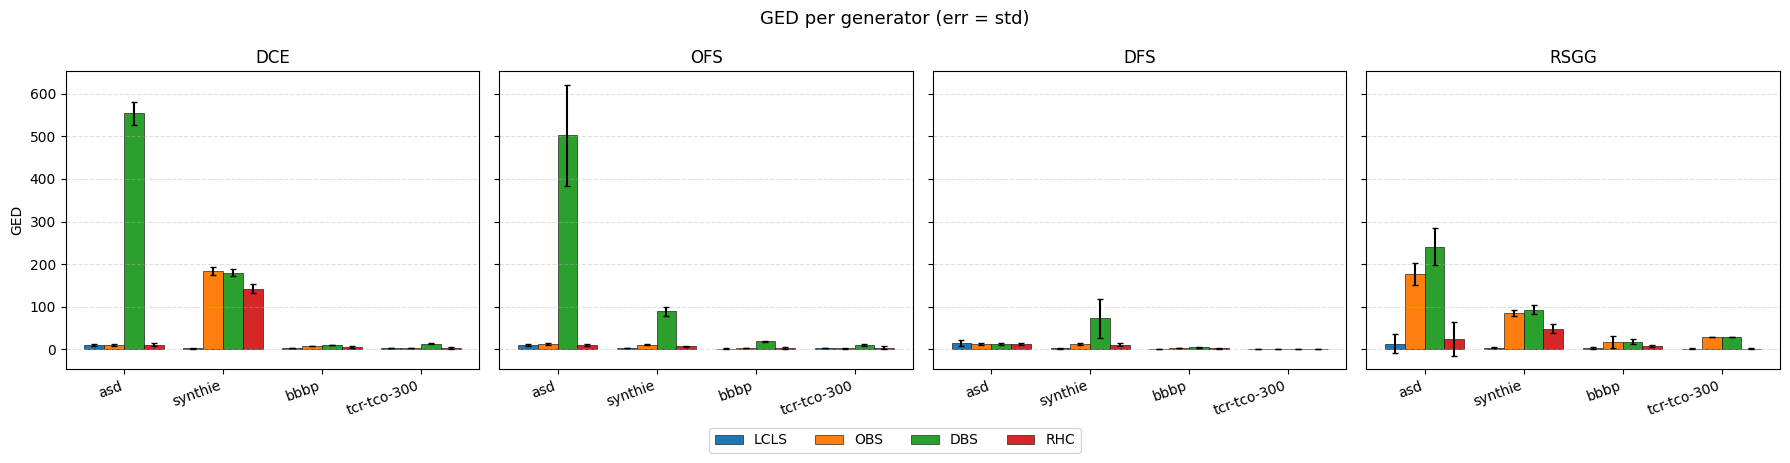

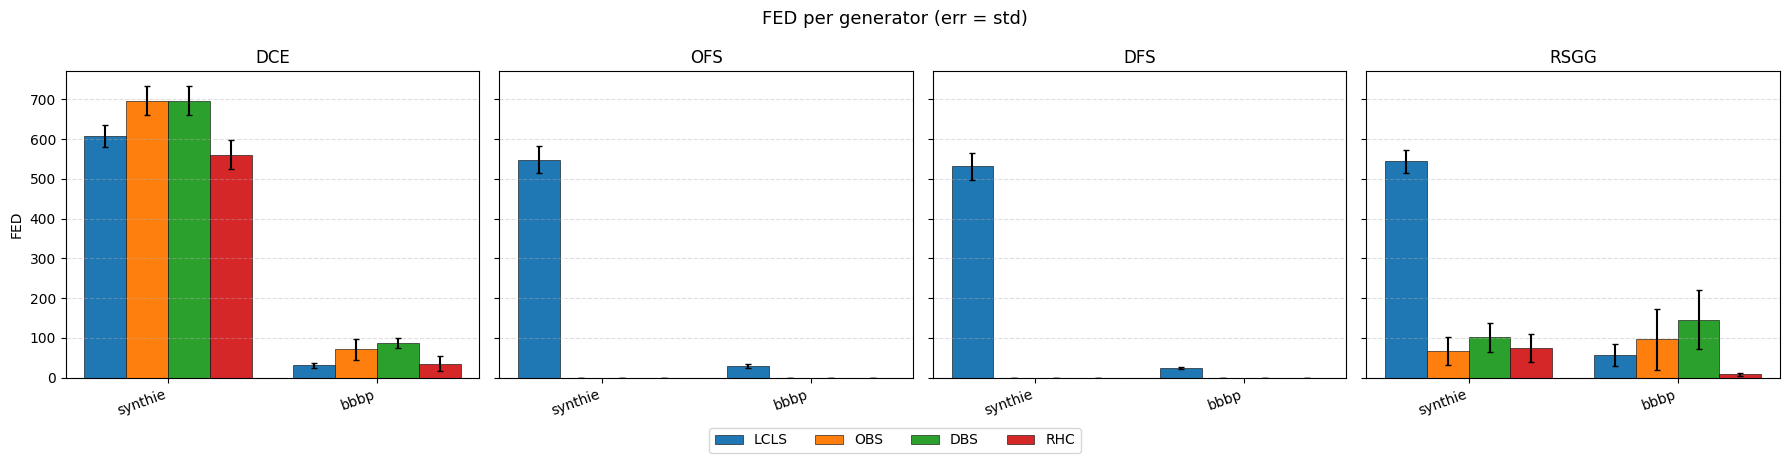

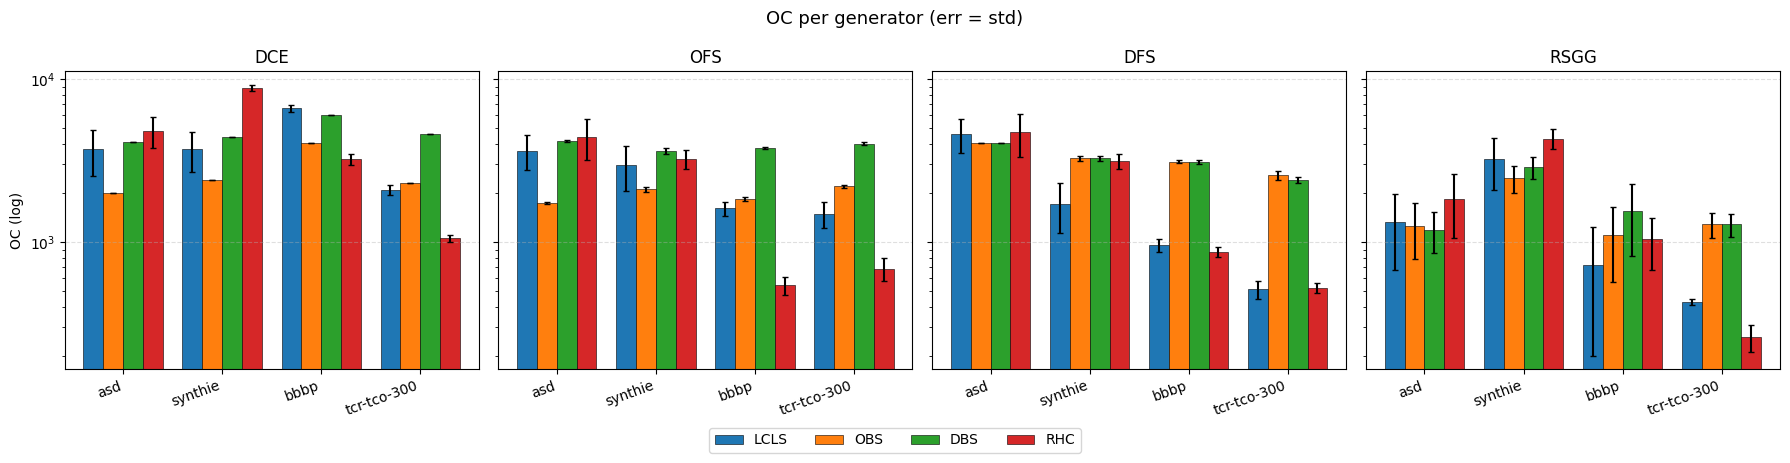

In [5]:
def bars_for_metric(metric, agg, log_scale=False, ymax=None):
    """Grouped bars for the paper's 4 minimizers (lcls/obs/dbs/rhc), one
    panel per generator. Error bars = std (pooled folds)."""
    sub = agg[agg['metric'] == metric].copy()
    if metric == 'FeatureEditDistance':
        sub = sub[sub['ds'].isin(ATTRIBUTED)]
    if sub.empty:
        print(f"(no data for {metric})")
        return None

    fig, axes = plt.subplots(1, len(GENERATORS), figsize=(18, 4.5), sharey=True)
    handles, labels = None, None
    palette = {'lcls': '#1f77b4', 'obs': '#ff7f0e', 'dbs': '#2ca02c', 'rhc': '#d62728'}
    width = 0.2
    for ax, gen in zip(axes, GENERATORS):
        sg = sub[sub['gen'] == gen]
        if sg.empty:
            ax.set_title(f"{gen.upper()} (no data)"); ax.set_xticks([]); continue
        ds_list = [d for d in DATASETS if d in sg['ds'].unique()]
        x = np.arange(len(ds_list))
        for idx, mn in enumerate(MINIMIZERS):
            means = [sg[(sg['ds']==d)&(sg['min_kind']==mn)]['mean'].mean() for d in ds_list]
            stds  = [sg[(sg['ds']==d)&(sg['min_kind']==mn)]['std'].mean() for d in ds_list]
            offset = (idx - (len(MINIMIZERS)-1)/2) * width
            ax.bar(x + offset, means, width, yerr=stds, capsize=2,
                   color=palette[mn], edgecolor='black', linewidth=0.4, label=mn.upper())
        ax.set_xticks(x); ax.set_xticklabels(ds_list, rotation=20, ha='right')
        ax.set_title(gen.upper()); ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()
    if log_scale:
        for ax in axes: ax.set_yscale('log')
    if ymax is not None:
        for ax in axes: ax.set_ylim(0, ymax)
    axes[0].set_ylabel(PRETTY[metric] + (' (log)' if log_scale else ''))
    fig.suptitle(f"{PRETTY[metric]} per generator (err = std)", fontsize=13)
    if handles:
        fig.legend(handles, labels, loc='lower center', ncol=len(MINIMIZERS),
                   bbox_to_anchor=(0.5, -0.02), frameon=True)
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    return fig

bars_for_metric('GraphEditDistance', agg_noseed_core); plt.show()
bars_for_metric('FeatureEditDistance', agg_noseed_core); plt.show()
bars_for_metric('OracleCalls', agg_noseed_core, log_scale=True); plt.show()


In [6]:
# === 4. E1 - Combined per-generator result figures -> lab/graphics ===
# Regenerates the four paper figures (DCE, OFS, DFS, RSGG). Each is a 2x2
# layout of GED / FED / Oracle Calls with a single shared legend; FED is
# shown only for the attributed datasets (BBBP, Synthie); the GED axis is
# capped at 100 (taller bars run off the panel but keep their exact label);
# the exact value is printed on every bar. Correctness is NOT a panel here
# (it is a generator property, reported once in section 3b / its table).
# The generator-only bar is drawn from the *_dummy cells when present, else
# as a hatched 'TODO' placeholder. Re-run after the remaining experiments
# (and the gen-only calibration) to refresh, then copy the PNGs into the
# paper's images/ directory.
import importlib, sys
if 'scripts' not in sys.path:
    sys.path.insert(0, 'scripts')
import make_paper_figures as mpf
importlib.reload(mpf)
mpf.generate_all(out_dir=mpf.LAB_GRAPHICS, defer_dummy=set())
print('figures written to', mpf.LAB_GRAPHICS)


wrote /home/rodrigo/projects/GRETEL stuff/GRETEL/lab/graphics/dce_results.png
wrote /home/rodrigo/projects/GRETEL stuff/GRETEL/lab/graphics/ofs_results.png
wrote /home/rodrigo/projects/GRETEL stuff/GRETEL/lab/graphics/dfs_results.png
wrote /home/rodrigo/projects/GRETEL stuff/GRETEL/lab/graphics/rsgg_results.png
figures written to /home/rodrigo/projects/GRETEL stuff/GRETEL/lab/graphics


## 5. E1 - Wilcoxon paired test (LBS vs OBS) on per-instance GED

Pairs are matched on `(seed, fold, instance_id)`. Within-generator
comparison only (R1.4). Two-sided.

In [7]:
def wilcoxon_lbs_vs_obs(df_long):
    # Pair on instances that are a valid counterfactual under BOTH methods,
    # so a GED=0 placeholder from a non-CF never enters the test.
    ged = df_long[(df_long['metric'] == 'GraphEditDistance') & (df_long['is_correct'])]
    rows = []
    for ds in DATASETS:
        for gen in GENERATORS:
            lbs = ged[(ged['ds']==ds) & (ged['gen']==gen) & (ged['min_kind']=='lcls')]
            obs = ged[(ged['ds']==ds) & (ged['gen']==gen) & (ged['min_kind']=='obs')]
            if lbs.empty or obs.empty:
                continue
            merged = lbs.merge(obs, on=['inst_id','fold','seed'],
                               suffixes=('_lbs','_obs'))
            if len(merged) < 5:
                continue
            try:
                stat, p = stats.wilcoxon(merged['value_lbs'], merged['value_obs'],
                                         zero_method='wilcox', alternative='two-sided')
            except ValueError as e:
                stat, p = float('nan'), float('nan')
            med_diff = (merged['value_lbs'] - merged['value_obs']).median()
            # Cliff-style effect size: fraction of pairs where LBS strictly better.
            better = (merged['value_lbs'] < merged['value_obs']).mean()
            rows.append({'ds': ds, 'gen': gen,
                         'n_pairs': len(merged),
                         'median(LBS-OBS)': med_diff,
                         'LBS < OBS (%)': 100*better,
                         'wilcoxon_W': stat,
                         'p_value': p})
    return pd.DataFrame(rows)

wilcoxon_lbs_vs_obs(df_long)


,ds,gen,n_pairs,median(LBS-OBS),LBS < OBS (%),wilcoxon_W,p_value
0,asd,dce,101,-0.081061,81.188119,1428.0,1.009335e-04
1,asd,ofs,78,0.103359,32.051282,1512.0,8.871010e-01
2,asd,dfs,101,0.000000,20.792079,233.0,5.604981e-01
3,asd,rsgg,43,-141.592982,97.674419,1.0,4.547474e-13
4,synthie,dce,400,-159.696838,100.000000,0.0,2.657928e-67
5,synthie,ofs,278,-6.354153,89.568345,1778.0,2.192972e-39
6,synthie,dfs,296,-6.000000,90.878378,28.5,3.720539e-46
7,synthie,rsgg,244,-72.269248,100.000000,0.0,8.876388e-42
8,bbbp,dce,2039,-1.399880,79.843060,362831.0,3.334813e-143
9,bbbp,ofs,1401,-0.744299,54.175589,309816.0,4.609944e-33


## 6. Table B - LBS stability over seeds (E1b)

The only multi-seed experiment: **LBS (lcls) + DCE**, per dataset, across
the no-seed run (= seed 0) plus `dce-lcls-seed{1,2,3}`. Reports
**mean ± std over the seeds** for GED / FED / OC, with `n_seeds` = how many
of the 4 seeds have data. This is the stochastic-stability evidence for
R1.5 / R2.12.

In [8]:
# Table B: LBS (lcls) + DCE, mean ± std OVER SEEDS (seed 0 = no-seed run,
# plus dce-lcls-seed{1,2,3}). Legacy is excluded (it is seedless).
def lbs_seed_table(per_seed, gen='dce', mn='lcls'):
    sub = per_seed[(per_seed['gen']==gen) & (per_seed['min_kind']==mn)
                   & (per_seed['seed'] != LEGACY_SEED)]
    rows = []
    for ds, g in sub.groupby('ds'):
        r = {'ds': ds}
        for metric in ['GraphEditDistance', 'FeatureEditDistance', 'OracleCalls']:
            mm = g[g['metric'] == metric]['value']
            d = DEC.get(metric, 2)
            if len(mm) == 0:
                r[PRETTY[metric]] = '-'
            elif len(mm) == 1:
                r[PRETTY[metric]] = f"{mm.mean():.{d}f} [n=1]"
            else:
                r[PRETTY[metric]] = f"{mm.mean():.{d}f} ± {mm.std():.{d}f}"
        # n_seeds = distinct seeds with any metric for this ds
        r['n_seeds'] = g['seed'].nunique()
        rows.append(r)
    out = pd.DataFrame(rows)
    if not out.empty and 'FED' in out.columns:
        out.loc[~out['ds'].isin(ATTRIBUTED), 'FED'] = '-'
    return out

tableB = lbs_seed_table(per_seed)
print("Table B - LBS+DCE stability across seeds {0(no-seed),1,2,3}")
tableB


Table B - LBS+DCE stability across seeds {0(no-seed),1,2,3}


,ds,GED,FED,OC,n_seeds
0,asd,9.58 ± 0.24,-,3777.5 ± 101.5,4
1,bbbp,2.53 ± 0.11,29.51 ± 1.93,4702.2 ± 1277.0,4
2,synthie,2.53 ± 0.34,589.64 ± 12.40,2853.5 ± 577.1,4
3,tcr-tco-300,2.48 ± 0.37,-,1305.3 ± 528.1,4


## 7. E3 - DCE ordering ablation (var-3 / var-4)

In [9]:
# E3: DCE ordering ablation. Canonical lcls vs the var-3/var-4 reorderings,
# across all datasets (same shape as the var-1/var-2 inclusion ablation).
E3_MINS = ['lcls', 'lcls-var-3', 'lcls-var-4']
E3_LABEL = {'lcls': 'canonical', 'lcls-var-3': 'var-3 (add>swap>1a>1b)',
            'lcls-var-4': 'var-4 (add>1b>1a>swap)'}
agg_e3 = agg_noseed[(agg_noseed['gen'] == 'dce')
                    & (agg_noseed['min_kind'].isin(E3_MINS))]
print("E3 ordering ablation on DCE (lcls vs var-3 vs var-4), per dataset:")
print("min_kinds present:", sorted(agg_e3['min_kind'].unique()))
e3_tbl = metric_table(agg_e3, min_order=E3_MINS, ds_order=DATASETS, group=True)
if not e3_tbl.empty and 'min' in e3_tbl.columns:
    e3_tbl.insert(list(e3_tbl.columns).index('min') + 1, 'ordering',
                  e3_tbl['min'].map(lambda m: E3_LABEL.get(m, '')))
e3_tbl

E3 ordering ablation on DCE (lcls vs var-3 vs var-4), per dataset:
min_kinds present: ['lcls', 'lcls-var-3', 'lcls-var-4']


,ds,gen,min,ordering,GED,GED-std,FED,FED-std,OC,OC-std
0,asd,dce,lcls,canonical,9.30,± 2.08,-,-,3716.4,± 1184.3
1,,,lcls-var-3,var-3 (add>swap>1a>1b),128.82,± 63.36,-,-,7164.4,± 1265.3
2,,,lcls-var-4,var-4 (add>1b>1a>swap),17.07,± 11.22,-,-,6227.0,± 1295.9
3,,,,,,,,,,
4,synthie,dce,lcls,canonical,2.73,± 0.99,608.03,± 26.95,3716.0,± 1020.8
5,,,lcls-var-3,var-3 (add>swap>1a>1b),4.07,± 3.09,578.95,± 22.79,3054.6,± 540.1
6,,,lcls-var-4,var-4 (add>1b>1a>swap),2.53,± 1.14,571.41,± 19.95,3014.9,± 635.7
7,,,,,,,,,,
8,bbbp,dce,lcls,canonical,2.38,± 0.18,31.20,± 5.98,6617.6,± 308.2
9,,,lcls-var-3,var-3 (add>swap>1a>1b),3.00,± 0.21,38.74,± 9.99,6048.5,± 348.9


## 7b. BLS variants (kept as DISTINCT minimizers)

The BLS family has several variants that are **separate minimizers** and
must never be merged with each other or with base BLS:

| min_kind | label | source |
|---|---|---|
| `lcls` | BLS | base bounded local search |
| `lcls-trainable` | BLS-Trainable | thesis (param training) |
| `lcls-ponderation` | BLS-Ponderation | thesis (weighted training) |
| `lcls-net` | BLS+Selector | thesis (selector net) |
| `lcls-net-trainable` | BLS+Selector+Trainable | **thesis final result** (dcem-bls-snt) |

These are excluded from the E1 matrix (not paper minimizers) but shown
here side by side per (dataset, generator). Each is its own `min_kind`
token, parsed exactly, so they are never mixed.

In [10]:
# BLS-family minimizers, each kept DISTINCT (never merged). No-seed runs.
BLS_VARIANTS = ['lcls', 'lcls-trainable', 'lcls-ponderation',
                'lcls-net', 'lcls-net-trainable']
BLS_LABEL = {'lcls': 'BLS', 'lcls-trainable': 'BLS-Trainable',
             'lcls-ponderation': 'BLS-Ponderation', 'lcls-net': 'BLS+Selector',
             'lcls-net-trainable': 'BLS+Selector+Trainable'}

agg_bls = agg_noseed[agg_noseed['min_kind'].isin(BLS_VARIANTS)].copy()
bls_tbl = metric_table(agg_bls, min_order=BLS_VARIANTS,
                       ds_order=sorted(agg_bls['ds'].unique()),
                       gen_order=sorted(agg_bls['gen'].unique()), group=False)
if not bls_tbl.empty:
    bls_tbl.insert(3, 'variant', bls_tbl['min'].map(BLS_LABEL))
print(f"distinct BLS min_kinds present: {sorted(agg_bls['min_kind'].unique())}")
bls_tbl


distinct BLS min_kinds present: ['lcls']


,ds,gen,min,variant,GED,GED-std,FED,FED-std,OC,OC-std
0,asd,dce,lcls,BLS,9.30,± 2.08,-,-,3716.4,± 1184.3
1,asd,dfs,lcls,BLS,14.33,± 6.92,-,-,4609.8,± 1087.9
2,asd,ofs,lcls,BLS,10.80,± 1.97,-,-,3649.1,± 872.9
3,asd,rsgg,lcls,BLS,13.26,± 21.88,-,-,1328.5,± 652.4
4,bbbp,dce,lcls,BLS,2.38,± 0.18,31.20,± 5.98,6617.6,± 308.2
5,bbbp,dfs,lcls,BLS,1.45,± 0.10,24.28,± 1.93,956.1,± 85.6
6,bbbp,ofs,lcls,BLS,1.81,± 0.07,29.38,± 5.36,1609.1,± 155.0
7,bbbp,rsgg,lcls,BLS,3.00,± 1.24,57.81,± 27.36,721.6,± 520.6
8,synthie,dce,lcls,BLS,2.73,± 0.99,608.03,± 26.95,3716.0,± 1020.8
9,synthie,dfs,lcls,BLS,2.09,± 0.42,531.15,± 34.72,1722.6,± 580.1


## 8. Coverage report

Quick look at how many of the 4×4×4×3 = 192 cells have data, so missing
runs are obvious before the paper.

In [11]:
# Coverage of the 64-cell no-seed matrix (4 ds x 4 gen x 4 min) + LBS seeds.
present = set(zip(agg_noseed_core['ds'], agg_noseed_core['gen'], agg_noseed_core['min_kind']))
expected = {(ds, gen, mn) for ds in DATASETS for gen in GENERATORS for mn in MINIMIZERS}
missing = sorted(expected - present)
print(f"No-seed matrix: expected={len(expected)}  present={len(present & expected)}  "
      f"missing={len(missing)}")
for cell in missing:
    print("  MISSING:", '_'.join(cell))

# LBS+DCE seed coverage (want seeds 0,1,2,3 per dataset).
print("\nLBS+DCE seeds present per dataset (target {0,1,2,3}):")
lbs = per_seed[(per_seed['gen']=='dce') & (per_seed['min_kind']=='lcls')
               & (per_seed['seed'] != LEGACY_SEED)]
for ds in DATASETS:
    seeds = sorted(lbs[lbs['ds']==ds]['seed'].unique())
    print(f"  {ds:<12} seeds={seeds}")


No-seed matrix: expected=64  present=64  missing=0

LBS+DCE seeds present per dataset (target {0,1,2,3}):
  asd          seeds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  synthie      seeds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  bbbp         seeds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  tcr-tco-300  seeds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## 9. Global per-scope aggregation (std over folds)

Same shape as section 5 of `1-evaluation_pipeline.ipynb`: one row per
`(scope, dataset, oracle, explainer)`, with each metric reported as
mean and std **across folds within that scope**. This is independent
of the seed-level std reported above - it tells you how much each
individual scope's metric varies fold-to-fold, which is the
fold-level dispersion the thesis tables use.

OracleAccuracy and Sparsity columns are dropped (not in the paper).
Rows are sorted by parsed `(dataset, generator, minimizer, seed)` so
both seeded and legacy unseeded scopes line up cleanly. CSV is saved
under `lab/stats/results_revision.csv`.

In [12]:
from src.data_analysis.future.data_analyzer import DataAnalyzer

stats_csv = 'lab/stats/results_revision.csv'

# cf-free section: aggregate BOTH stores. 'store' marks where each scope
# came from (legacy = seedless thesis/paper runs without cf dumps).
frames = []
for store, path in [('results', 'lab/output/results'),
                    ('legacy',  'lab/output/results-legacy')]:
    if Path(path).is_dir() and any(Path(path).rglob('results_*.json')):
        d = DataAnalyzer.create_aggregated_dataframe(path)
        d.insert(1, 'store', store)
        frames.append(d)
res = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# Drop the columns not in the paper (R2.8: only GED/FED/OC/Correctness +
# Runtime as a sanity column).
drop_cols = [c for c in res.columns
             if c.startswith(('OracleAccuracy', 'Sparsity'))]
res = res.drop(columns=drop_cols)

# Sort by parsed (ds, gen, min, seed); legacy scopes sort with seed=-1 first.
def _scope_parts(scope):
    p = parse_scope(scope)
    if p is not None:
        return p
    p = parse_scope(scope, legacy=True)
    if p is not None:
        return p
    parts = str(scope).rsplit('_', 2)
    if len(parts) == 3:
        return (parts[0], parts[1], parts[2], -2)
    return ('?', '?', str(scope), -2)

_p = res['scope'].apply(_scope_parts)
res[['_ds', '_gen', '_min', '_seed']] = pd.DataFrame(_p.tolist(), index=res.index)
res = (res.sort_values(['_ds', '_gen', '_min', '_seed'],
                       kind='stable', na_position='last')
          .drop(columns=['_ds', '_gen', '_min', '_seed'])
          .reset_index(drop=True))

os.makedirs(os.path.dirname(stats_csv), exist_ok=True)
res.to_csv(stats_csv, index=False)
print(f"saved {len(res)} rows to {stats_csv}  ({len(res.columns)} columns)")
res


saved 133 rows to lab/stats/results_revision.csv  (15 columns)


,scope,store,dataset,oracle,explainer,Runtime,Runtime-std,GraphEditDistance,GraphEditDistance-std,FeatureEditDistance,FeatureEditDistance-std,Correctness,Correctness-std,OracleCalls,OracleCalls-std
0,aids_dcm_lcls-net-trainable,legacy,AIDS-196bfc784dde399b8a913e5706c8669b,OracleTorch-3d12f86f6853c575b5dbafdbedd376eb,GenerateMinimize(DCM-LocalSearch),72.511390,2.361574,11.803000,0.768600,67.468504,7.946167,1.000000,0.000000,1133.124000,38.873773
1,aids_dfs_dbs,legacy,AIDS-196bfc784dde399b8a913e5706c8669b,OracleTorch-3d12f86f6853c575b5dbafdbedd376eb,GenerateMinimize(DFS-DBS),10.101920,13.804947,482.050649,446.144307,0.000000,0.000000,0.039000,0.011576,1025.515000,36.783150
2,aids_ofs_obs,legacy,AIDS-196bfc784dde399b8a913e5706c8669b,OracleTorch-3d12f86f6853c575b5dbafdbedd376eb,GenerateMinimize(OFS-OBS),3.544209,2.459894,6.693795,0.489857,0.000000,0.000000,0.051000,0.011576,2120.652000,26.533129
3,asd_dce_dbs,results,ASD-15273954d84e872cf0b021cd4477bfdc,ASDOracle-9e4f3586dc330143b7849fc540b25739,GenerateMinimize(DCESExplainer-DBS),1.724349,0.032619,553.877273,25.102450,0.000000,0.000000,1.000000,0.000000,4106.000000,0.000000
4,asd_dce_dummy,results,ASD-15273954d84e872cf0b021cd4477bfdc,ASDOracle-9e4f3586dc330143b7849fc540b25739,GenerateMinimize(DCESExplainer-Dummy),0.212269,0.026374,1011.747273,5.479443,0.000000,0.000000,1.000000,0.000000,104.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,tcr-tco-300_rsgg_dbs,results,TreeCyclesRand-3756eb685e0fa99a8eb0f257b31fa9fa,TreeCyclesOracle-bf771b62d9c9e71304534ab5bb138005,GenerateMinimize(RSGG-DBS),10.823035,4.309134,28.452159,0.364096,0.000000,0.000000,0.831667,0.053980,1285.516667,194.497793
129,tcr-tco-300_rsgg_dummy,results,TreeCyclesRand-3756eb685e0fa99a8eb0f257b31fa9fa,TreeCyclesOracle-bf771b62d9c9e71304534ab5bb138005,GenerateMinimize(RSGG-Dummy),63.629230,177.386236,51.802048,0.246774,834.277222,22.570642,0.791667,0.063792,110.850000,31.748322
130,tcr-tco-300_rsgg_lcls,results,TreeCyclesRand-3756eb685e0fa99a8eb0f257b31fa9fa,TreeCyclesOracle-bf771b62d9c9e71304534ab5bb138005,GenerateMinimize(RSGG-LocalSearch),3.990024,0.654920,1.790000,0.192080,56.060000,0.133750,0.840000,0.033500,428.480000,17.701067
131,tcr-tco-300_rsgg_obs,results,TreeCyclesRand-3756eb685e0fa99a8eb0f257b31fa9fa,TreeCyclesOracle-bf771b62d9c9e71304534ab5bb138005,GenerateMinimize(RSGG-OBS),6.107498,0.916466,28.410000,0.430979,219.370000,0.639087,0.821667,0.058238,1288.200000,212.542704
